# 🎓 Training Pipeline – Integral Action Classifier
Xử lý dữ liệu mất cân bằng và tối ưu hiệu suất model.

In [29]:
import pandas as pd
import sys, os, re
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../..'))

%pip install matplotlib scikit-learn imbalanced-learn -q

from collections import Counter
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from ai.utils.integral import Integral
from ai.utils.printer import Printer
from ai.utils.expr.expr_node import ExprNode
from ai.utils.expr.trig.expr_sin import SinExprNode
from ai.utils.expr.trig.expr_cos import CosExprNode
from ai.utils.expr.trig.expr_tan import TanExprNode
from ai.utils.expr.operation.expr_add import AddExprNode
from ai.utils.expr.operation.expr_sub import SubExprNode
from ai.utils.expr.operation.expr_mul import MulExprNode
from ai.utils.expr.operation.expr_frac import FracExprNode
from ai.utils.expr.value.expr_var import VarExprNode
from ai.utils.expr.value.expr_const import ConstExprNode
from ai.utils.expr.Power.expr_mono import MonoExprNode
from ai.utils.expr.expr_log import LogExprNode
from ai.utils.expr.Power.expr_sqrt import SqrtExprNode
from ai.utils.expr.Power.expr_power import PowerExprNode

print('✅ Project imports OK')

✅ Project imports OK


## 📊 1. Load & Phân tích dữ liệu

📦 Tổng mẫu: 647
📐 Features: 79
🏷️  Classes: [0, 1, 2, 3, 4, 6, 7, 8]

📊 Phân phối nhãn:
  action=0: 56 (8.7%)
  action=1: 251 (38.8%)
  action=2: 2 (0.3%)
  action=3: 17 (2.6%)
  action=4: 1 (0.2%)
  action=6: 15 (2.3%)
  action=7: 247 (38.2%)
  action=8: 58 (9.0%)


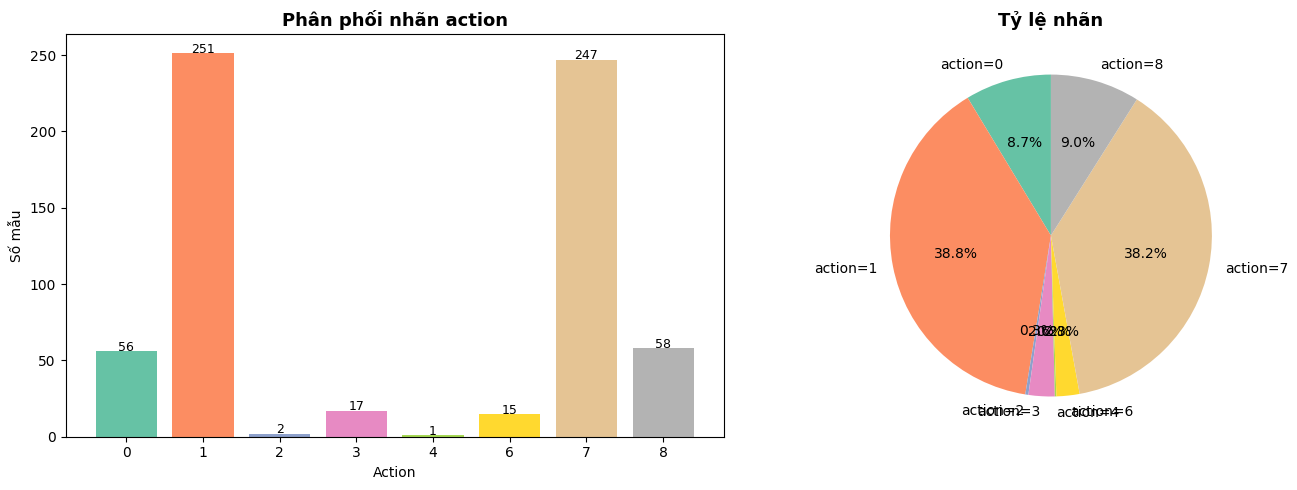

💾 Đã lưu label_distribution.png


In [31]:
df = pd.read_csv('../data/processed/integral_dataset.csv')
# df = df.head(2500)

# Đảm bảo label là số nguyên
df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')
df = df.dropna(subset=['label'])

y = df['label'].astype(int)
X = df.drop(columns=['label'])

print(f'📦 Tổng mẫu: {len(df)}')
print(f'📐 Features: {X.shape[1]}')
print(f'🏷️  Classes: {sorted(y.unique())}')

cnt = Counter(y)
print('\n📊 Phân phối nhãn:')
for k in sorted(cnt): 
    print(f'  action={k}: {cnt[k]} ({cnt[k]/len(y)*100:.1f}%)')

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = sorted(cnt.keys())
values = [cnt[k] for k in labels]
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

axes[0].bar([str(l) for l in labels], values, color=colors)
axes[0].set_title('Phân phối nhãn action', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('Số mẫu')
for i, v in enumerate(values):
    axes[0].text(i, v+0.2, str(v), ha='center', fontsize=9)

axes[1].pie(values, labels=[f'action={l}' for l in labels],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Tỷ lệ nhãn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('💾 Đã lưu label_distribution.png')

## ⚖️ 2. Xử lý mất cân bằng – Class Weights

In [32]:
classes = np.unique(y)
class_weights = compute_class_weight('balanced', classes=classes, y=y)
cw_dict = dict(zip(classes, class_weights))

print('⚖️  Class weights (balanced):')
for k in sorted(cw_dict):
    bar = '█' * int(cw_dict[k])
    print(f'  action={k:3d}: {cw_dict[k]:.3f}  {bar}')

⚖️  Class weights (balanced):
  action=  0: 1.444  █
  action=  1: 0.322  
  action=  2: 40.438  ████████████████████████████████████████
  action=  3: 4.757  ████
  action=  4: 80.875  ████████████████████████████████████████████████████████████████████████████████
  action=  6: 5.392  █████
  action=  7: 0.327  
  action=  8: 1.394  █


## 🔗 3. Gộp nhãn hiếm (class có < 3 mẫu)

Class `action=2` chỉ có 1 mẫu → gộp vào `action=0` (unknown) để tránh lỗi cross-validation.

In [33]:
# Đếm số mẫu mỗi class
cnt = Counter(y)
MIN_SAMPLES = 16  # ngưỡng tối thiểu để giữ class riêng
rare_classes = [k for k, v in cnt.items() if v < MIN_SAMPLES]

if rare_classes:
    print(f'⚠️  Nhãn hiếm (< {MIN_SAMPLES} mẫu): {rare_classes} → gộp vào action=0')
    y_clean = y.copy()
    for rc in rare_classes:
        y_clean = y_clean.replace(rc, 3)
else:
    y_clean = y.copy()
    print('✅ Không có nhãn hiếm')

print(f'\n📊 Phân phối sau khi xử lý:')
cnt2 = Counter(y_clean)
for k in sorted(cnt2):
    print(f'  action={k}: {cnt2[k]}')

⚠️  Nhãn hiếm (< 16 mẫu): [6, 2, 4] → gộp vào action=0

📊 Phân phối sau khi xử lý:
  action=0: 56
  action=1: 251
  action=3: 35
  action=7: 247
  action=8: 58


## ✂️ 4. Train/Test Split (Stratified)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print(f'🔀 Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu')

# Tính class weights trên tập train
classes_train = np.unique(y_train)
cw_train = compute_class_weight('balanced', classes=classes_train, y=y_train)
cw_dict_train = dict(zip(classes_train, cw_train))
print(f'⚖️  Class weights train: {cw_dict_train}')

🔀 Train: 517 mẫu | Test: 130 mẫu
⚖️  Class weights train: {0: 2.2977777777777777, 1: 0.5144278606965174, 3: 3.692857142857143, 7: 0.5248730964467005, 8: 2.247826086956522}


## 🤖 5. Model 1: SVM với Class Weight Balanced

In [35]:
# Số fold tự động theo class nhỏ nhất
min_count = min(Counter(y_train).values())
n_splits = min(5, min_count)
print(f'ℹ️  Dùng {n_splits}-fold CV (min class count = {min_count})')

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
])

param_grid_svm = [
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto', 0.01, 0.1]},
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10]},
    {'svm__kernel': ['poly'], 'svm__C': [0.1, 1, 10], 'svm__degree': [2, 3]}
]

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

gs_svm = GridSearchCV(
    svm_pipeline, param_grid_svm, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=0
)

print('🔍 Đang chạy GridSearchCV SVM...')
gs_svm.fit(X_train, y_train)
print(f'\n🏆 SVM Best params: {gs_svm.best_params_}')
print(f'🏆 SVM Best CV F1-macro: {gs_svm.best_score_:.4f}')

y_pred_svm = gs_svm.predict(X_test)
f1_svm = f1_score(y_test, y_pred_svm, average='macro', zero_division=0)
print(f'\n📊 SVM Test F1-macro: {f1_svm:.4f}')
print(classification_report(y_test, y_pred_svm, zero_division=0))

ℹ️  Dùng 5-fold CV (min class count = 28)
🔍 Đang chạy GridSearchCV SVM...

🏆 SVM Best params: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
🏆 SVM Best CV F1-macro: 0.6574

📊 SVM Test F1-macro: 0.6291
              precision    recall  f1-score   support

           0       0.40      0.36      0.38        11
           1       0.95      0.82      0.88        50
           3       0.19      0.57      0.29         7
           7       1.00      0.76      0.86        50
           8       0.61      0.92      0.73        12

    accuracy                           0.75       130
   macro avg       0.63      0.69      0.63       130
weighted avg       0.85      0.75      0.79       130



## 🌲 6. Model 2: Random Forest (tốt với imbalanced)

In [36]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    ))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(
    rf_pipeline, param_grid_rf, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=0
)

print('🔍 Đang chạy GridSearchCV Random Forest...')
gs_rf.fit(X_train, y_train)
print(f'\n🏆 RF Best params: {gs_rf.best_params_}')
print(f'🏆 RF Best CV F1-macro: {gs_rf.best_score_:.4f}')

y_pred_rf = gs_rf.predict(X_test)
# f1_rf = f1_score(y_test, y_pred_rf, average='macro', zero_vision=0)
# print(f'\n📊 RF Test F1-macro: {f1_rf:.4f}')
# print(classification_report(y_test, y_pred_rf, zero_division=0))

🔍 Đang chạy GridSearchCV Random Forest...

🏆 RF Best params: {'rf__max_depth': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
🏆 RF Best CV F1-macro: 0.6825


## 🚀 7. Model 3: Gradient Boosting

In [37]:
from sklearn.ensemble import GradientBoostingClassifier

# Sample weights từ class_weight
sample_weights = np.array([cw_dict_train.get(label, 1.0) for label in y_train])

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, random_state=42
)

print('🔍 Đang train Gradient Boosting...')
gb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb.predict(X_test)
f1_gb = f1_score(y_test, y_pred_gb, average='macro', zero_division=0)
print(f'\n📊 GB Test F1-macro: {f1_gb:.4f}')
print(classification_report(y_test, y_pred_gb, zero_division=0))

🔍 Đang train Gradient Boosting...

📊 GB Test F1-macro: 0.6194
              precision    recall  f1-score   support

           0       0.38      0.45      0.42        11
           1       0.86      0.76      0.81        50
           3       0.21      0.43      0.29         7
           7       0.78      0.76      0.77        50
           8       0.90      0.75      0.82        12

    accuracy                           0.72       130
   macro avg       0.63      0.63      0.62       130
weighted avg       0.76      0.72      0.73       130



## 🧬 8. SMOTE – Oversampling nhãn thiểu số

Tạo thêm mẫu tổng hợp cho các class ít dữ liệu.

In [38]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    # SMOTE chỉ hoạt động khi mỗi class có ít nhất 2 mẫu
    cnt_train = Counter(y_train)
    valid_classes = [k for k, v in cnt_train.items() if v >= 2]
    mask = y_train.isin(valid_classes)
    X_tr_sm, y_tr_sm = X_train[mask], y_train[mask]

    k_neighbors = min(3, min(Counter(y_tr_sm).values()) - 1)
    smote = SMOTE(k_neighbors=max(1, k_neighbors), random_state=42)
    X_res, y_res = smote.fit_resample(X_tr_sm, y_tr_sm)

    print(f'✅ SMOTE: {len(y_tr_sm)} → {len(y_res)} mẫu')
    print('Phân phối sau SMOTE:', Counter(y_res))

    # Train SVM trên dữ liệu SMOTE
    svm_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(class_weight='balanced', probability=True, random_state=42,
                    kernel='rbf', C=10, gamma='scale'))
    ])
    svm_smote.fit(X_res, y_res)
    y_pred_smote = svm_smote.predict(X_test)
    f1_smote = f1_score(y_test, y_pred_smote, average='macro', zero_division=0)
    print(f'\n📊 SVM+SMOTE Test F1-macro: {f1_smote:.4f}')
    print(classification_report(y_test, y_pred_smote, zero_division=0))

except ImportError:
    f1_smote = 0
    print('⚠️  imbalanced-learn chưa cài. Chạy: pip install imbalanced-learn')

✅ SMOTE: 517 → 1005 mẫu
Phân phối sau SMOTE: Counter({1: 201, 3: 201, 7: 201, 8: 201, 0: 201})

📊 SVM+SMOTE Test F1-macro: 0.6350
              precision    recall  f1-score   support

           0       0.32      0.55      0.40        11
           1       0.77      0.80      0.78        50
           3       0.29      0.29      0.29         7
           7       0.93      0.76      0.84        50
           8       0.91      0.83      0.87        12

    accuracy                           0.74       130
   macro avg       0.64      0.64      0.63       130
weighted avg       0.78      0.74      0.75       130



## 🏅 9. So sánh các Model


🏅 BẢNG SO SÁNH MODEL
  SVM + SMOTE              : 0.6350 ← 🥇 BEST
  SVM (balanced)           : 0.6291
  Gradient Boosting        : 0.6194


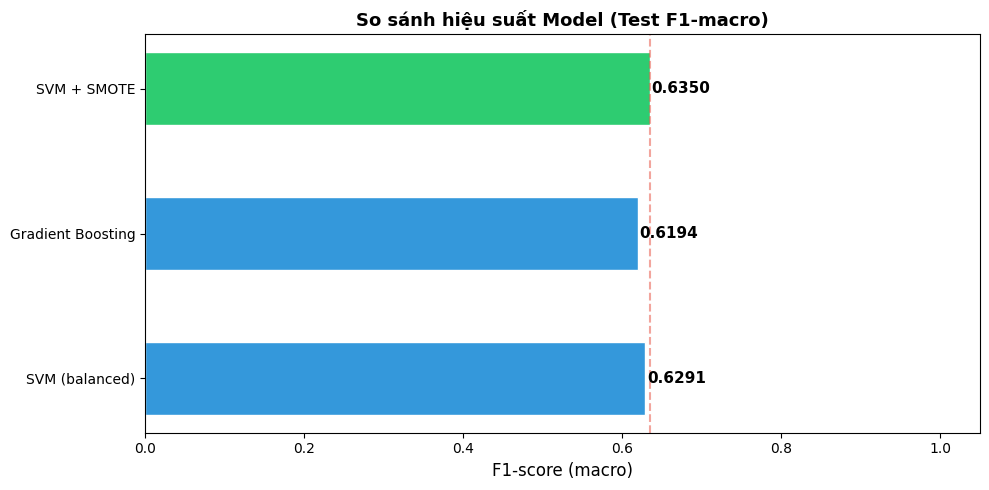

💾 Đã lưu model_comparison.png


In [39]:
results = {
    'SVM (balanced)': f1_svm,
    # 'Random Forest': f1_rf,
    'Gradient Boosting': f1_gb,
    'SVM + SMOTE': f1_smote
}

print('\n' + '='*45)
print('🏅 BẢNG SO SÁNH MODEL')
print('='*45)
best_name = max(results, key=results.get)
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    marker = ' ← 🥇 BEST' if name == best_name else ''
    print(f'  {name:25s}: {score:.4f}{marker}')
print('='*45)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
scores = list(results.values())
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]
bars = ax.barh(names, scores, color=colors, edgecolor='white', height=0.5)
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-score (macro)', fontsize=12)
ax.set_title('So sánh hiệu suất Model (Test F1-macro)', fontsize=13, fontweight='bold')
ax.axvline(x=scores[names.index(best_name)], color='#e74c3c', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print('💾 Đã lưu model_comparison.png')

## 💾 10. Lưu Model tốt nhất

In [40]:
import joblib, os

save_dir = '../saved_models'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'best_model.pkl')
joblib.dump(gb, model_path)
print(f'✅ Đã lưu best model: {best_name}')
print(f'   → {model_path}')
print(f'   F1-macro (test): {results[best_name]:.4f}')

# Lưu meta info
import json
meta = {
    'best_model': best_name,
    'f1_macro_test': results[best_name],
    'all_results': {k: round(v, 4) for k, v in results.items()},
    'n_classes': len(sorted(y_clean.unique())),
    'classes': sorted(int(c) for c in y_clean.unique())
}
with open(os.path.join(save_dir, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('📋 Đã lưu model_meta.json')

✅ Đã lưu best model: SVM + SMOTE
   → ../saved_models\best_model.pkl
   F1-macro (test): 0.6350
📋 Đã lưu model_meta.json
